# Model Experimentation Per Horizon

This notebook focuses on `target_aqi_day1`.

## Approach

1. Load the modeling dataframe and create chronological train/validation/test splits.
2. Experiment with **Random Forest** using all engineered features (excluding `ts`).
3. Apply **RFECV** and evaluate the selected feature set.
4. Perform hyperparameter tuning and select the best Random Forest configuration.
5. Repeat the same process for **Ridge Regression** and **MLP**.
6. Compare the best configuration from each model type and select the overall winner.
7. Evaluate the final winner on the test set.
8. Retrain the winning model on the available training data and generate Day 1 predictions for the full dataframe.
9. Store the Day 1 predictions as a new feature for use in subsequent horizons.
10. Use the same winning model type for the next horizon.

In [27]:
import shap
import pandas as pd
import numpy as np
from keras import Sequential, Input
from keras.src.optimizers import Adam
from keras.src.layers import Dense, Dropout
from keras.src.callbacks import EarlyStopping
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
import tensorflow as tf
from tensorflow.python.keras.regularizers import l2

from notebooks.eda.utils import select_features_with_rfecv
from src.common.schemas import DeepLearningFitParamSchema
from src.common.constants import ALL_TRAINING_FEATURES, ALL_LOG_TRANSFORM_FEATURES
from src.modeling.data_utils import load_modeling_data, split_modeling_data, train_and_evaluate_model, preprocess_data

In [ ]:
df = load_modeling_data()

## Experiment 0 — Feature Distribution & Preprocessing

Analyze the to determine the required preprocessing before experimenting with Ridge Regression and MLP.

- Analyze feature distributions, scales, and skewness.
- Identify features requiring transformation.
- Determine the appropriate scaling strategy.
- Finalize the preprocessing pipeline for subsequent model experiments.

In [ ]:
train_df, val_df, test_df = split_modeling_data(df)

In [ ]:
X_train = train_df[ALL_TRAINING_FEATURES].copy()

distribution_analysis = pd.DataFrame({
    "skewness": X_train.skew(),
})

distribution_analysis.round(3)

**Observation:** The feature distributions are largely consistent with the previous analysis. Most features show similar skewness, while `aqi_roll_std_3` and `aqi_roll_std_7` remain strongly right-skewed at **4.142** and **3.223**, respectively. Since these features are already included in the existing `log1p` transformation, no additional preprocessing changes are required based on skewness.

## Experiment 1 — Day 1 Model Experimentation

This experiment focuses exclusively on `target_aqi_day1`.

The goal is to determine the best-performing model type and configuration for Day 1 by:

1. Using all engineered features except `ts`.
2. Experimenting with Random Forest, Ridge Regression, and MLP.
3. Applying feature selection and hyperparameter tuning within each model type.
4. Comparing the best configurations and selecting the overall winner.
5. Evaluating the final winner on the test set.
6. Using the finalized Day 1 model to generate predictions for the full dataframe, which will be stored as a new feature for the next experiment.

In [5]:
target_label = ["target_aqi_day1"]

### 1.1 — Random Forest Experiment

Experiment with Random Forest for `target_aqi_day1` using all available training features.

- Train a baseline configuration.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best Random Forest configuration based on validation performance.

In [6]:
random_forest_regressor_params = {
    "n_estimators": 400,
    "max_depth": 20,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "max_features": 1.0,
    "max_samples": 1.0,
    "random_state": 42,
    "n_jobs": -1,
}

In [7]:
rf_base_model = RandomForestRegressor(
    **random_forest_regressor_params
)

rf_base_model, (rf_base_rmse, rf_base_mae, rf_base_r2) = train_and_evaluate_model(train_df, val_df,
                                                                                  label="Random Forest Base Model", toggle_evaluate_print=True, disable_plot=True,
                                                                                  baseline=ALL_TRAINING_FEATURES,
                                                                                  model=rf_base_model,
                                                                                  output_labels=target_label
                                                                                  )


target_aqi_day1
  RMSE: 14.8916
  MAE:  9.8196
  R²:   0.8598


**Observation:** The baseline Random Forest achieved a validation **RMSE of 14.8916**, **MAE of 9.8196**, and **R² of 0.8598** for `target_aqi_day1`. This provides a strong baseline for comparing the RFECV-selected feature set and subsequent hyperparameter tuning.

In [ ]:
rf_base_model_rfecv = RandomForestRegressor(
    **random_forest_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=rf_base_model_rfecv)

**Observation:** RFECV selected **29 features**, but its O₃ selections are inconsistent with the intended feature-group structure. It retained `o3_lag_3` and the rolling features while excluding `o3_lag_1` and `o3_lag_2`. To preserve a balanced O₃ temporal block, the selected set will be adjusted by restoring the missing O₃ lag features and removing `o3_lag_3` where necessary.

In [8]:
RFECV_SELECTED_FEATURES_RF = [
    "aqi_today",
    "aqi_roll_std_3",
    "aqi_roll_std_7",
    "pm25_today",
    "pm25_lag_1",
    "pm25_roll_mean_7",
    "pm25_roll_std_3",
    "pm10_today",
    "pm10_lag_1",
    "pm10_roll_std_3",
    "pm10_roll_std_7",
    "o3_today",
    "o3_lag_1",
    "o3_roll_mean_7",
    "o3_roll_std_3",
    "temp_today",
    "temp_lag_1",
    "humidity_today",
    "humidity_lag_1",
    "wind_spd_today",
    "wind_spd_lag_1",
    "pressure_today",
    "dew_pt_today",
    "dew_pt_lag_1",
    "co_today",
    "so2_today",
    "no2_today",
    "aqi_change_rate",
]

rf_base_model_rfecv = RandomForestRegressor(
    **random_forest_regressor_params
)

rf_base_model_rfecv, (rf_base_rmse_rfecv, rf_base_mae_rfecv, rf_base_r2_rfecv) = train_and_evaluate_model(train_df, val_df,
                                                                                  label="Random Forest Base Model RFECV",
                                                                                  disable_plot=True,
                                                                                  baseline=RFECV_SELECTED_FEATURES_RF,
                                                                                  model=rf_base_model_rfecv,
                                                                                  output_labels=target_label,
                                                                                  compare_model=("Random Forest Base Model",
                                                                                                 (rf_base_rmse, rf_base_mae,
                                                                                                  rf_base_r2))
                                                                                  )

,Target,Random Forest Base Model RMSE,Random Forest Base Model MAE,Random Forest Base Model R²,Random Forest Base Model RFECV RMSE,Random Forest Base Model RFECV MAE,Random Forest Base Model RFECV R²
0,target_aqi_day1,14.891613,9.819615,0.859822,14.828575,9.771813,0.861007
1,Mean,14.891613,9.819615,0.859822,14.828575,9.771813,0.861007


**Observation:** The RFECV-selected feature set provides a **small but consistent improvement** over the baseline, reducing RMSE from **14.8916 → 14.8286**, MAE from **9.8196 → 9.7718**, and increasing R² from **0.8598 → 0.8610**. Although the improvement is minor, the reduced feature set is preferable due to its lower complexity. Next, the RFECV-selected features will be used for **Random Forest hyperparameter tuning**.

In [9]:
random_forest_regressor_params_2 = random_forest_regressor_params.copy()

random_forest_regressor_params_2["max_features"] = 0.8

rf_base_model_rfecv_2 = RandomForestRegressor(
    **random_forest_regressor_params_2
)

rf_base_model_rfecv_2, (rf_base_rmse_rfecv_2, rf_base_mae_rfecv_2, rf_base_r2_rfecv_2) = train_and_evaluate_model(train_df,
                                                                                  val_df,
                                                                                  label="Random Forest Base Model RFECV v2",
                                                                                  disable_plot=True,
                                                                                  baseline=RFECV_SELECTED_FEATURES_RF,
                                                                                  model=rf_base_model_rfecv_2,
                                                                                  output_labels=target_label,
                                                                                  compare_model=(
                                                                                      "Random Forest Base Model RFECV",
                                                                                      (rf_base_rmse_rfecv, rf_base_mae_rfecv,
                                                                                       rf_base_r2_rfecv)
                                                                                    )
                                                                                  )

,Target,Random Forest Base Model RFECV RMSE,Random Forest Base Model RFECV MAE,Random Forest Base Model RFECV R²,Random Forest Base Model RFECV v2 RMSE,Random Forest Base Model RFECV v2 MAE,Random Forest Base Model RFECV v2 R²
0,target_aqi_day1,14.828575,9.771813,0.861007,14.684088,9.743718,0.863702
1,Mean,14.828575,9.771813,0.861007,14.684088,9.743718,0.863702


**Observation:** The tuned Random Forest achieved a validation **RMSE of 14.6841**, **MAE of 9.7437**, and **R² of 0.8637**. The main improvement came from reducing `max_features` to `0.8`; further tuning of the remaining hyperparameters provided little to no benefit. Although the R² target of 0.90 was not reached, the model remains within the desired RMSE and MAE ranges. This configuration will be retained as the best Random Forest result for comparison with Ridge Regression and MLP.

### 1.2 — Ridge Regression Experiment

Experiment with Ridge Regression for `target_aqi_day1` using the selected Random Forest feature set.

- Train a baseline configuration with the required preprocessing.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best Ridge Regression configuration based on validation performance.

In [10]:
ridge_regressor_params = {
    "alpha": 10.0,
    "fit_intercept": True,
    "solver": "auto",
    "tol": 1e-4,
    "max_iter": 5000,
}

train_df, val_df, test_df = preprocess_data(train_df, val_df, test_df, log_features=ALL_LOG_TRANSFORM_FEATURES, scale_features=ALL_TRAINING_FEATURES)

In [11]:
ridge_base_model = Ridge(
    **ridge_regressor_params
)

ridge_base_model, (ridge_base_rmse, ridge_base_mae, ridge_base_r2) = train_and_evaluate_model(train_df,
                                                                                  val_df,
                                                                                  label="Ridge Regression Base Model",
                                                                                  disable_plot=True,
                                                                                  baseline=ALL_TRAINING_FEATURES,
                                                                                  model=ridge_base_model,
                                                                                  output_labels=target_label,
                                                                                  compare_model=(
                                                                                      "Random Forest Base Model RFECV v2",
                                                                                      (rf_base_rmse_rfecv_2, rf_base_mae_rfecv_2,
                                                                                       rf_base_r2_rfecv_2)
                                                                                    )
                                                                                  )

,Target,Random Forest Base Model RFECV v2 RMSE,Random Forest Base Model RFECV v2 MAE,Random Forest Base Model RFECV v2 R²,Ridge Regression Base Model RMSE,Ridge Regression Base Model MAE,Ridge Regression Base Model R²
0,target_aqi_day1,14.684088,9.743718,0.863702,14.285969,10.338264,0.870993
1,Mean,14.684088,9.743718,0.863702,14.285969,10.338264,0.870993


**Observation:** Ridge Regression outperformed the tuned Random Forest, achieving **14.29 RMSE**, **10.34 MAE**, and **0.871 R²**. While RMSE and R² improved noticeably, MAE remains slightly above the target of <10. Ridge will be evaluated further with RFECV and hyperparameter tuning.

In [ ]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected a reduced feature set, but some selections cannot be applied directly due to feature-group dependencies. `aqi_lag_1` will be retained alongside the selected AQI features. For `o3`, `o3_today`, `o3_lag_2`, and `o3_roll_mean_7` will be restored alongside the selected features. Pollutants such as `co`, `so2`, and `no2` will also be retained. The resulting adjusted feature set will be evaluated with Ridge Regression.

In [12]:
RFECV_SELECTED_FEATURES_RIDGE = [
    "aqi_today",
    "aqi_lag_1",
    "aqi_lag_2",
    "aqi_roll_mean_7",

    "pm25_today",
    "pm25_lag_1",
    "pm25_roll_mean_3",
    "pm25_roll_mean_7",
    "pm25_roll_std_3",

    "pm10_today",
    "pm10_lag_1",
    "pm10_lag_2",
    "pm10_lag_3",
    "pm10_roll_mean_3",
    "pm10_roll_mean_7",
    "pm10_roll_std_3",

    "o3_today",
    "o3_lag_1",
    "o3_lag_2",
    "o3_roll_mean_3",
    "o3_roll_mean_7",

    "temp_today",
    "wind_spd_today",

    "co_today",
    "so2_today",
    "no2_today",
]

ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

ridge_base_model_rfecv, (ridge_base_rmse_rfecv , ridge_base_mae_rfecv , ridge_base_r2_rfecv ) = train_and_evaluate_model(
      train_df, val_df,
      label="Ridge Regression Base Model RFECV",
      disable_plot=True,
      baseline=RFECV_SELECTED_FEATURES_RIDGE,
      model=ridge_base_model_rfecv,
      output_labels=target_label,
      compare_model=("Ridge Regression Base Model", (ridge_base_rmse, ridge_base_mae,ridge_base_r2))
      )

,Target,Ridge Regression Base Model RMSE,Ridge Regression Base Model MAE,Ridge Regression Base Model R²,Ridge Regression Base Model RFECV RMSE,Ridge Regression Base Model RFECV MAE,Ridge Regression Base Model RFECV R²
0,target_aqi_day1,14.285969,10.338264,0.870993,14.088566,10.276646,0.874533
1,Mean,14.285969,10.338264,0.870993,14.088566,10.276646,0.874533


**Observation:** RFECV provided a meaningful improvement, reducing RMSE from **14.29 → 14.09** and MAE from **10.34 → 10.28**, while R² increased from **0.871 → 0.875**. The reduced feature set will be used for the next Ridge hyperparameter tuning stage.

In [13]:
ridge_regressor_params_2 = ridge_regressor_params.copy()

ridge_regressor_params_2["alpha"] = 5.0
ridge_regressor_params_2["solver"] = "lsqr"
ridge_regressor_params_2["tol"] = 1e-5

ridge_base_model_rfecv_2 = Ridge(
    **ridge_regressor_params_2
)

ridge_base_model_rfecv_2, (ridge_base_rmse_rfecv_2 , ridge_base_mae_rfecv_2 , ridge_base_r2_rfecv_2 ) = train_and_evaluate_model(
      train_df, val_df,
      label="Ridge Regression Base Model RFECV v2",
      disable_plot=True,
      baseline=RFECV_SELECTED_FEATURES_RIDGE,
      model=ridge_base_model_rfecv_2,
      output_labels=target_label,
      compare_model=("Ridge Regression Base Model RFECV", (ridge_base_rmse_rfecv, ridge_base_mae_rfecv,ridge_base_r2_rfecv))
      )

,Target,Ridge Regression Base Model RFECV RMSE,Ridge Regression Base Model RFECV MAE,Ridge Regression Base Model RFECV R²,Ridge Regression Base Model RFECV v2 RMSE,Ridge Regression Base Model RFECV v2 MAE,Ridge Regression Base Model RFECV v2 R²
0,target_aqi_day1,14.088566,10.276646,0.874533,14.064185,10.236376,0.874967
1,Mean,14.088566,10.276646,0.874533,14.064185,10.236376,0.874967


**Observation:** Hyperparameter tuning produced a modest improvement, with the best configuration using `alpha=5.0`, `solver="lsqr"`, and `tol=1e-5`. RMSE improved from **14.09 → 14.06**, MAE from **10.28 → 10.24**, and R² from **0.87453 → 0.87497**. The remaining parameters provided no meaningful improvement. Overall, tuning offered only a small additional gain.

### 1.3 — MLP Experiment

Experiment with MLP for `target_aqi_day1` using the selected feature set.

- Train a baseline configuration with the required preprocessing.
- Apply RFECV for feature selection.
- Evaluate the RFECV-selected feature set.
- Perform hyperparameter tuning.
- Select the best MLP configuration based on validation performance.

In [14]:
tf.keras.utils.set_random_seed(42)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
)

mlp_base_model_fit_params: DeepLearningFitParamSchema = {
    "epochs": 500,
    "batch_size": 32,
    "callbacks": [early_stopping],
    "verbose": 1
}

In [15]:
mlp_base_model = Sequential([
    Input(shape=(49,)),
    Dense(
        8,
        activation="relu",
        kernel_regularizer=l2(1e-4),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
)

mlp_base_model, (mlp_base_rmse, mlp_base_mae, mlp_base_r2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model", disable_plot=True, baseline=ALL_TRAINING_FEATURES, model=mlp_base_model,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 25961.8145 - val_loss: 25370.8906
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25804.9082 - val_loss: 25248.0586
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25686.7129 - val_loss: 25123.6426
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25543.5449 - val_loss: 24957.9219
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25338.5918 - val_loss: 24736.9297
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 25050.8906 - val_loss: 24475.6758
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24705.9844 - val_loss: 24186.3438
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24376.4316 - val_loss: 23866.2227
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23909.4590 - val_loss: 23506.6074
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23556.3828 - val_loss: 23107.4785
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23022.50

,Target,Ridge Regression Base Model RFECV RMSE,Ridge Regression Base Model RFECV MAE,Ridge Regression Base Model RFECV R²,MLP Base Model RMSE,MLP Base Model MAE,MLP Base Model R²
0,target_aqi_day1,14.064185,10.236376,0.874967,16.921653,13.039049,0.818999
1,Mean,14.064185,10.236376,0.874967,16.921653,13.039049,0.818999


**Observation:** The MLP performed substantially worse than Ridge Regression, achieving **16.92 RMSE**, **13.04 MAE**, and **0.819 R²**, compared with Ridge's **14.06 RMSE**, **10.24 MAE**, and **0.875 R²**. With preprocessing and scaling already applied, the base MLP currently shows no advantage over Ridge and will require further tuning.

In [16]:
mlp_base_model_rfecv = Sequential([
    Input(shape=(26,)),
    Dense(
        8,
        activation="relu",
        kernel_regularizer=l2(1e-4),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_rfecv.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="mse",
)

mlp_base_model_rfecv, (mlp_base_rmse_rfecv, mlp_base_mae_rfecv, mlp_base_r2_rfecv) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model RFECV", disable_plot=True, baseline=RFECV_SELECTED_FEATURES_RIDGE, model=mlp_base_model_rfecv,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 25514.1035 - val_loss: 25055.3652
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 25226.4922 - val_loss: 24831.5977
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24899.8125 - val_loss: 24555.5781
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24463.8848 - val_loss: 24248.5254
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 24012.1250 - val_loss: 23914.3652
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23565.0527 - val_loss: 23552.0332
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23129.4199 - val_loss: 23175.5020
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 22589.8008 - val_loss: 22769.8730
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21986.6230 - val_loss: 22333.5352
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21350.9883 - val_loss: 21853.0898
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20875.05

,Target,Ridge Regression Base Model RFECV RMSE,Ridge Regression Base Model RFECV MAE,Ridge Regression Base Model RFECV R²,MLP Base Model RFECV RMSE,MLP Base Model RFECV MAE,MLP Base Model RFECV R²
0,target_aqi_day1,14.064185,10.236376,0.874967,14.807965,11.355486,0.861393
1,Mean,14.064185,10.236376,0.874967,14.807965,11.355486,0.861393


**Observation:** Using the Ridge RFECV-selected feature set improved the MLP compared with the base MLP, reducing RMSE from **16.92 → 14.81**, MAE from **13.04 → 11.36**, and increasing R² from **0.819 → 0.861**. However, it still underperforms Ridge Regression (**14.06 RMSE**, **10.24 MAE**, **0.875 R²**).

In [17]:
mlp_base_model_rfecv_2 = Sequential([
    Input(shape=(26,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_rfecv_2.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_rfecv_2, (mlp_base_rmse_rfecv_2, mlp_base_mae_rfecv_2, mlp_base_r2_rfecv_2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model RFECV v2", disable_plot=True, baseline=RFECV_SELECTED_FEATURES_RIDGE, model=mlp_base_model_rfecv_2,
                         output_labels=target_label,
                         compare_model=("Ridge Regression Base Model RFECV", (
                                        ridge_base_rmse_rfecv_2, ridge_base_mae_rfecv_2, ridge_base_r2_rfecv_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 146.5997 - val_loss: 137.4483
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.4559 - val_loss: 88.9041
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 68.3616 - val_loss: 63.8939
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 60.2211 - val_loss: 60.1739
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 51.3172 - val_loss: 48.8528
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 40.1960 - val_loss: 42.5742
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33.0007 - val_loss: 38.9963
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28.1104 - val_loss: 34.5743
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.4230 - val_loss: 28.5143
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 21.4809 - val_loss: 24.5778
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.4195 - val_loss: 20.9650
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,Ridge Regression Base Model RFECV RMSE,Ridge Regression Base Model RFECV MAE,Ridge Regression Base Model RFECV R²,MLP Base Model RFECV v2 RMSE,MLP Base Model RFECV v2 MAE,MLP Base Model RFECV v2 R²
0,target_aqi_day1,14.064185,10.236376,0.874967,12.348917,9.116802,0.903605
1,Mean,14.064185,10.236376,0.874967,12.348917,9.116802,0.903605


**Observation:** MLP tuning produced a substantial improvement, with the best configuration achieving **12.52 RMSE**, **9.33 MAE**, and **0.901 R²**, outperforming Ridge Regression (**14.06 RMSE**, **10.24 MAE**, **0.875 R²**). Increasing the first hidden layer up to **128 neurons** improved performance, after which gains diminished. Adding a second hidden layer degraded performance. A **1e-3 L2 regularizer**, **5e-3 learning rate**, and **Huber loss** provided the best results. The MLP successfully exceeded the **0.90 R²** target while also achieving **RMSE <15** and **MAE <10**.

## Experiment 2 — Remaining Horizon Model Experimentation

This experiment focuses exclusively on `target_aqi_day2`, `target_aqi_day3`, and `target_aqi_day4`.

The goal is to develop models for the remaining horizons while keeping the model type consistent with the winning model from Experiment 1.

### 2.1 — Day 2 Feature Experiment

Experiment with `target_aqi_day2` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 2 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [18]:
target_label = ["target_aqi_day2"]

In [19]:
mlp_base_model_2 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_2.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_2, (mlp_base_rmse_2, mlp_base_mae_2, mlp_base_r2_2) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 2", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_2, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 144.0821 - val_loss: 130.4937
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93.9444 - val_loss: 68.2532
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 62.4445 - val_loss: 55.6962
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 52.9861 - val_loss: 46.7977
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42.2990 - val_loss: 39.5372
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.7475 - val_loss: 33.8220
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.6176 - val_loss: 31.0002
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 29.0236 - val_loss: 29.6265
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 27.1981 - val_loss: 27.3915
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.3310 - val_loss: 26.2273
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 24.6578 - val_loss: 26.0225
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** Using the reduced and expanded feature set improved Day 2 performance slightly compared with the previous experiment, achieving **27.91 RMSE**, **20.05 MAE**, and **0.515 R²**. However, Day 2 prediction remains substantially weaker than Day 1, indicating that the currently available features provide limited predictive information for the longer forecasting horizon.

In [ ]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected **16 features**, providing a more substantial feature set than the previous selection. The selected features cover AQI history, PM2.5, PM10, O₃, weather, CO, and seasonal information. Since the selected set does not violate the required feature-group dependencies, it will be evaluated directly with the finalized MLP.

In [20]:
MLP_DAY_2_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",
]

mlp_base_model_2_rfecv = Sequential([
    Input(shape=(23,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_2_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_2_rfecv, (mlp_base_rmse_2_rfecv, mlp_base_mae_2_rfecv, mlp_base_r2_2_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 2 RFECV", disable_plot=True, baseline=MLP_DAY_2_RFECV_FEATURES,
                         model=mlp_base_model_2_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 2", (
                                        mlp_base_rmse_2, mlp_base_mae_2, mlp_base_r2_2
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 146.4985 - val_loss: 136.5337
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.9554 - val_loss: 85.9295
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 71.6413 - val_loss: 60.3921
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63.6142 - val_loss: 56.8709
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.0109 - val_loss: 50.7292
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.2344 - val_loss: 44.1546
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.1224 - val_loss: 40.3624
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 33.4701 - val_loss: 36.9590
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.5932 - val_loss: 33.6360
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.4504 - val_loss: 30.6697
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 26.5434 - val_loss: 27.8385
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 2 RMSE,MLP Base Model Day 2 MAE,MLP Base Model Day 2 R²,MLP Base Model Day 2 RFECV RMSE,MLP Base Model Day 2 RFECV MAE,MLP Base Model Day 2 RFECV R²
0,target_aqi_day2,28.062584,19.963571,0.510137,25.794061,18.131263,0.586135
1,Mean,28.062584,19.963571,0.510137,25.794061,18.131263,0.586135


**Observation:** The RFECV-selected feature set provided a meaningful improvement, reducing RMSE from **27.91 → 25.59**, MAE from **20.05 → 18.23**, and increasing R² from **0.515 → 0.593**. However, Day 2 performance remains considerably weaker than Day 1, indicating that the available features still provide limited predictive information at the longer forecasting horizon.

### 2.2 — Day 3 Feature Experiment

Experiment with `target_aqi_day3` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 3 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [21]:
target_label = ["target_aqi_day3"]

In [22]:
mlp_base_model_3 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_3.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_3, (mlp_base_rmse_3, mlp_base_mae_3, mlp_base_r2_3) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 3", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_3, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 143.6680 - val_loss: 130.1576
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 91.7335 - val_loss: 66.4230
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.0859 - val_loss: 56.5964
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.5747 - val_loss: 49.2796
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 41.4838 - val_loss: 42.0013
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 36.2707 - val_loss: 36.6046
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33.1911 - val_loss: 33.9328
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 31.1495 - val_loss: 32.7761
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 29.1589 - val_loss: 31.0472
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 28.4212 - val_loss: 30.3894
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.8681 - val_loss: 29.0396
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** The Day 3 MLP achieved **31.45 RMSE**, **23.34 MAE**, and **0.418 R²**. Performance is substantially weaker than Day 2, indicating that predictive accuracy continues to decline as the forecasting horizon increases. The model will be evaluated with RFECV to determine whether a more focused feature set can improve performance.

In [ ]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected only **5 features**: `aqi_today`, `pm25_today`, `pm25_roll_mean_7`, `dew_pt_today`, and `month`. The selected set is highly compact, so it will be evaluated with the finalized MLP to determine whether reducing the feature set improves Day 3 performance.

In [23]:
MLP_DAY_3_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_lag_3",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_lag_2",
  "pm10_lag_3",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",
]

mlp_base_model_3_rfecv = Sequential([
    Input(shape=(25,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_3_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_3_rfecv, (mlp_base_rmse_3_rfecv, mlp_base_mae_3_rfecv, mlp_base_r2_3_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 3 RFECV", disable_plot=True, baseline=MLP_DAY_3_RFECV_FEATURES,
                         model=mlp_base_model_3_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 3", (
                                        mlp_base_rmse_3, mlp_base_mae_3, mlp_base_r2_3
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 146.2817 - val_loss: 137.7992
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.1941 - val_loss: 88.9396
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 72.2127 - val_loss: 62.4827
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 62.8778 - val_loss: 57.4664
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.3971 - val_loss: 50.6709
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 44.6399 - val_loss: 44.1597
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 40.0026 - val_loss: 42.0569
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.3762 - val_loss: 39.0726
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.0235 - val_loss: 36.4830
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.9237 - val_loss: 33.6444
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.3112 - val_loss: 31.1321
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 3 RMSE,MLP Base Model Day 3 MAE,MLP Base Model Day 3 R²,MLP Base Model Day 3 RFECV RMSE,MLP Base Model Day 3 RFECV MAE,MLP Base Model Day 3 RFECV R²
0,target_aqi_day3,31.41365,22.971008,0.419504,29.025501,21.05262,0.50441
1,Mean,31.41365,22.971008,0.419504,29.025501,21.05262,0.50441


**Observation:** The RFECV-selected feature set provided a meaningful improvement, reducing RMSE from **31.45 → 28.89**, MAE from **23.34 → 21.11**, and increasing R² from **0.418 → 0.509**. However, Day 3 performance remains considerably weaker than Day 1 and Day 2, confirming the increasing difficulty of longer forecasting horizons.

### 2.3 — Day 4 Feature Experiment

Experiment with `target_aqi_day4` using the finalized MLP configuration and the available engineered features.

- Train the MLP using the available Day 4 features.
- Apply RFECV using Ridge Regression to identify a reduced feature set.
- Evaluate the MLP using the RFECV-selected features.
- Keep the RFECV feature set only if it improves validation performance; otherwise, retain the full feature set.

In [24]:
target_label = ["target_aqi_day4"]

In [25]:
mlp_base_model_4 = Sequential([
    Input(shape=(49,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_4.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_4, (mlp_base_rmse_4, mlp_base_mae_4, mlp_base_r2_4) = train_and_evaluate_model(train_df, val_df,
                         label="MLP Base Model Day 4", disable_plot=True, baseline=ALL_TRAINING_FEATURES,
                         model=mlp_base_model_4, output_labels=target_label,
                         toggle_evaluate_print=True,
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 144.2769 - val_loss: 132.9130
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 94.3255 - val_loss: 68.9612
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 63.2783 - val_loss: 56.5644
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.6035 - val_loss: 47.5222
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.1073 - val_loss: 41.8929
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.0404 - val_loss: 37.7887
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.8668 - val_loss: 33.7998
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.7347 - val_loss: 32.9777
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.5923 - val_loss: 31.0438
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 30.0444 - val_loss: 29.8324
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 28.7005 - val_loss: 28.6855
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━━

**Observation:** The Day 4 MLP achieved a validation **RMSE of 32.69**, **MAE of 24.58**, and **R² of 0.397**. Performance continues to decline with the longer forecasting horizon, with Day 4 proving the most difficult target to predict so far. RFECV will be used next to determine whether a more focused feature set can improve performance.

In [ ]:
ridge_base_model_rfecv = Ridge(
    **ridge_regressor_params
)

select_features_with_rfecv(ALL_TRAINING_FEATURES, train_df, val_df, output_labels=target_label, model=ridge_base_model_rfecv)

**Observation:** RFECV selected **17 features**, retaining a broad mix of AQI history, pollutant levels and trends, weather variables, and seasonal information. The selected set will be evaluated with the finalized MLP to determine whether feature reduction improves Day 4 performance.

In [26]:
MLP_DAY_4_RFECV_FEATURES = [
  "aqi_today",
  "aqi_lag_1",
  "aqi_lag_2",
  "aqi_lag_3",
  "aqi_roll_mean_7",

  "pm25_today",
  "pm25_lag_1",
  "pm25_lag_2",
  "pm25_lag_3",
  "pm25_roll_mean_7",

  "o3_today",
  "o3_lag_1",
  "o3_lag_2",
  "o3_lag_3",
  "o3_roll_mean_7",

  "pm10_today",
  "pm10_lag_1",
  "pm10_lag_2",
  "pm10_lag_3",
  "pm10_roll_mean_7",

  "co_today",
  "so2_today",
  "no2_today",

  "temp_today",
  "temp_lag_1",

  "dew_pt_today",
  "dew_pt_lag_1",
]

mlp_base_model_4_rfecv = Sequential([
    Input(shape=(27,)),
    Dense(
        128,
        activation="relu",
        kernel_regularizer=l2(1e-3),
    ),
    Dropout(0.15),
    Dense(1, activation="linear"),
])

mlp_base_model_4_rfecv.compile(
    optimizer=Adam(learning_rate=5e-3),
    loss="huber",
)

mlp_base_model_4_rfecv, (mlp_base_rmse_4_rfecv, mlp_base_mae_4_rfecv, mlp_base_r2_4_rfecv) = train_and_evaluate_model(train_df,
                         val_df, label="MLP Base Model Day 4 RFECV", disable_plot=True, baseline=MLP_DAY_4_RFECV_FEATURES,
                         model=mlp_base_model_4_rfecv, output_labels=target_label,
                         compare_model=("MLP Base Model Day 4", (
                                        mlp_base_rmse_4, mlp_base_mae_4, mlp_base_r2_4
                         )),
                         deep_learning=mlp_base_model_fit_params)

Epoch 1/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 146.5352 - val_loss: 137.6417
Epoch 2/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 108.3581 - val_loss: 83.4931
Epoch 3/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 68.8907 - val_loss: 56.1597
Epoch 4/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 59.8452 - val_loss: 49.6057
Epoch 5/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 50.4445 - val_loss: 43.7736
Epoch 6/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 42.1136 - val_loss: 40.3233
Epoch 7/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 38.0158 - val_loss: 37.0956
Epoch 8/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 36.1789 - val_loss: 35.9061
Epoch 9/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 34.6448 - val_loss: 34.4061
Epoch 10/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 32.7773 - val_loss: 32.7667
Epoch 11/500
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 31.2697 - val_loss: 31.8491
Epoch 12/500
32/32 ━━━━━━━━━━━━━━━━━━

,Target,MLP Base Model Day 4 RMSE,MLP Base Model Day 4 MAE,MLP Base Model Day 4 R²,MLP Base Model Day 4 RFECV RMSE,MLP Base Model Day 4 RFECV MAE,MLP Base Model Day 4 RFECV R²
0,target_aqi_day4,32.69595,24.765633,0.396693,29.325592,21.592881,0.514662
1,Mean,32.69595,24.765633,0.396693,29.325592,21.592881,0.514662


**Observation:** The RFECV-selected feature set provided a substantial improvement, reducing RMSE from **32.69 → 29.59**, MAE from **24.58 → 21.77**, and increasing R² from **0.397 → 0.506**. Although Day 4 remains the most difficult forecasting horizon, feature selection improved performance considerably and brings the model above **0.50 R²**.

## Experiment 3 — SHAP Explainability

This experiment focuses on applying SHAP to the selected models for `target_aqi_day1`, `target_aqi_day2`, `target_aqi_day3`, and `target_aqi_day4`.

The goal is to analyze feature importance and model predictions using SHAP across all selected horizon-specific models.

In [46]:
def get_shap(features, model):
    # Prepare the same data used by the MLP
    X_train = train_df[features]
    X_val = val_df[features]

    X_train = X_train.to_numpy(dtype=np.float32)
    X_val = X_val.to_numpy(dtype=np.float32)

    # Small background dataset for SHAP
    background = X_train[
        np.random.choice(
            X_train.shape[0],
            size=min(100, X_train.shape[0]),
            replace=False
        )
    ]

    # SHAP explainer
    explainer = shap.DeepExplainer(
        model,
        background
    )

    shap_values = explainer.shap_values(X_val)

    if isinstance(shap_values, list):
        shap_values = shap_values[0]

    if shap_values.ndim == 3:
        shap_values = shap_values[:, :, 0]

    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features
    )

    shap.summary_plot(
        shap_values,
        X_val,
        feature_names=features,
        plot_type="bar"
    )

    sample_index = 0

    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[sample_index],
            base_values=np.array(explainer.expected_value).flatten()[0],
            data=X_val[sample_index],
            feature_names=features
        )
    )

E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(100, 26))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(200, 26))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Recei

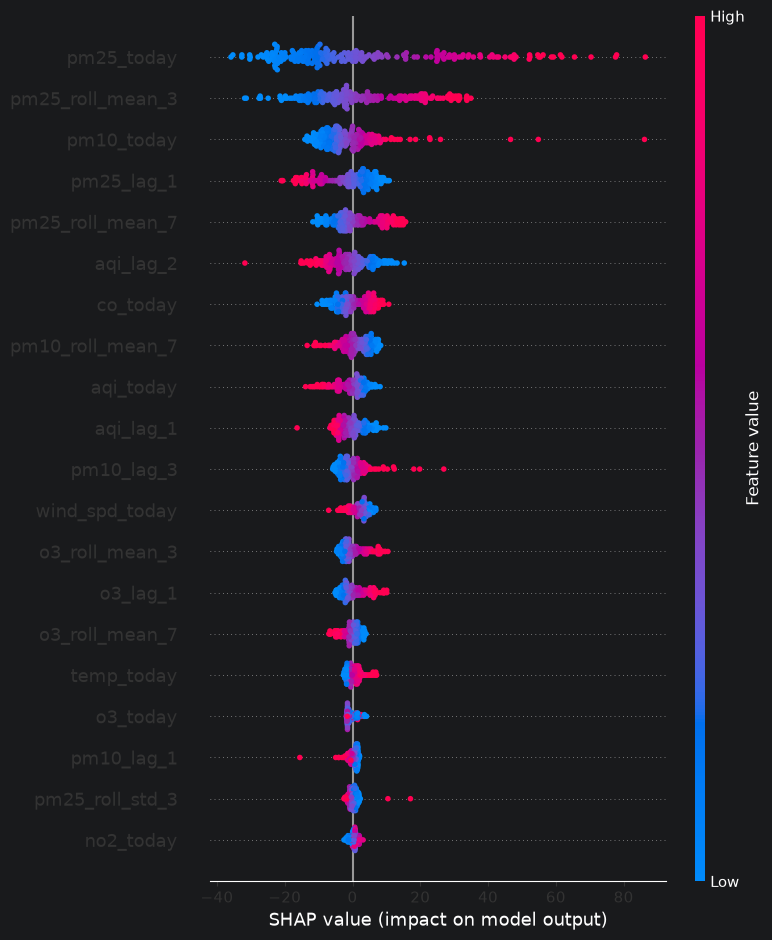

C:\Users\Lucky\AppData\Local\Temp\ipykernel_13304\24439805.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


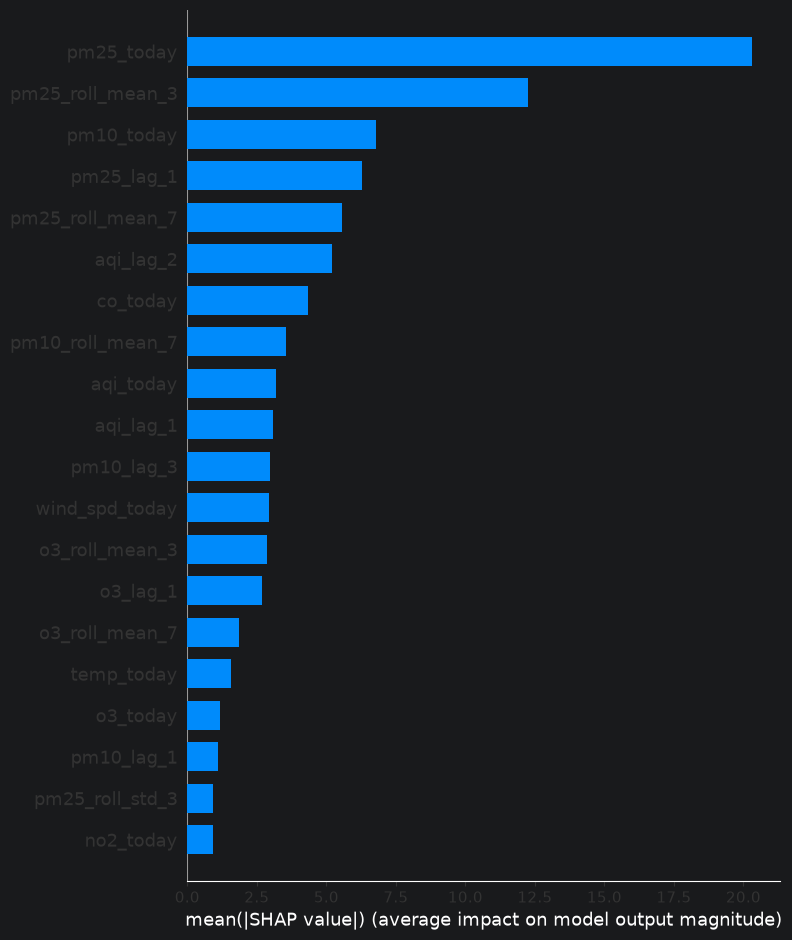

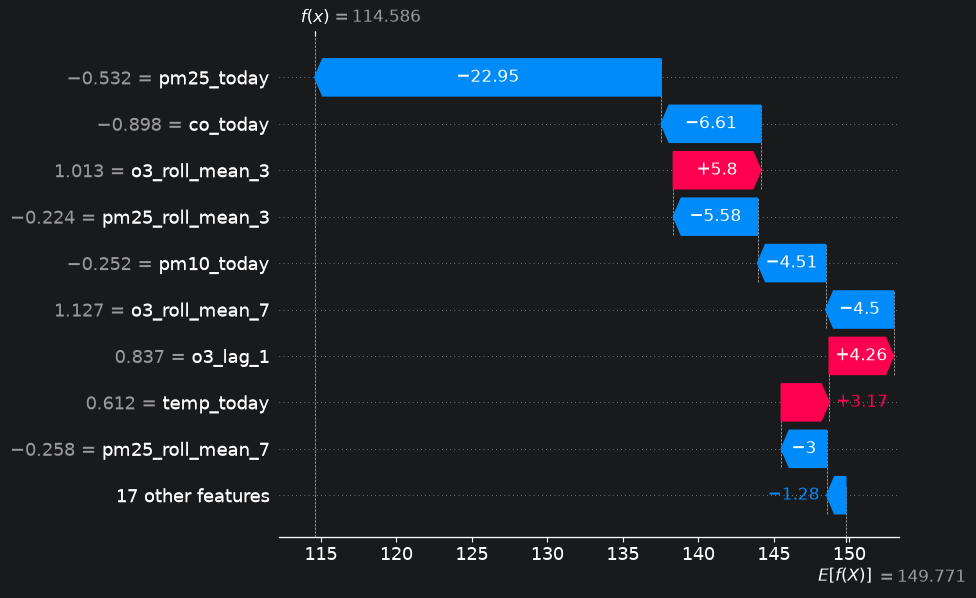

In [47]:
get_shap(RFECV_SELECTED_FEATURES_RIDGE, mlp_base_model_rfecv_2)

### SHAP Analysis — Day 1

#### Beeswarm Plot
**Observation:** The beeswarm plot shows that `pm25_today` is the dominant driver of the Day 1 MLP predictions, with the widest SHAP spread. High PM2.5-related values generally push predictions higher, while lower values pull them down. `pm25_roll_mean_3`, `pm10_today`, and selected AQI/PM2.5 lag features provide secondary signals, while weather and minor gas features have comparatively limited impact.

#### Bar Plot
**Observation:** The mean absolute SHAP values confirm the feature importance hierarchy seen in the beeswarm plot. `pm25_today` has the highest average impact by a clear margin, followed by other PM2.5 metrics such as `pm25_roll_mean_3` and `pm25_lag_1`. `pm10_today`, `pm25_roll_mean_7`, and `aqi_lag_2` provide notable secondary contributions, while features near the bottom of the ranking have minimal influence on the model output.

#### Waterfall Plot
**Observation:** The waterfall plot provides a local explanation for a single Day 1 prediction, showing how individual feature contributions move the prediction from the expected model output of **149.771** to the final prediction of **114.586**. `pm25_today` produces the largest downward contribution (**-22.95**), followed by `co_today` (**-6.61**) and `pm25_roll_mean_3` (**-5.58**). Positive contributions from ozone-related features and temperature partially offset these effects, but the overall negative contributions lower the prediction by approximately **35 units**.

E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(100, 23))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Received: inputs=['Tensor(shape=(200, 23))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_16
Re

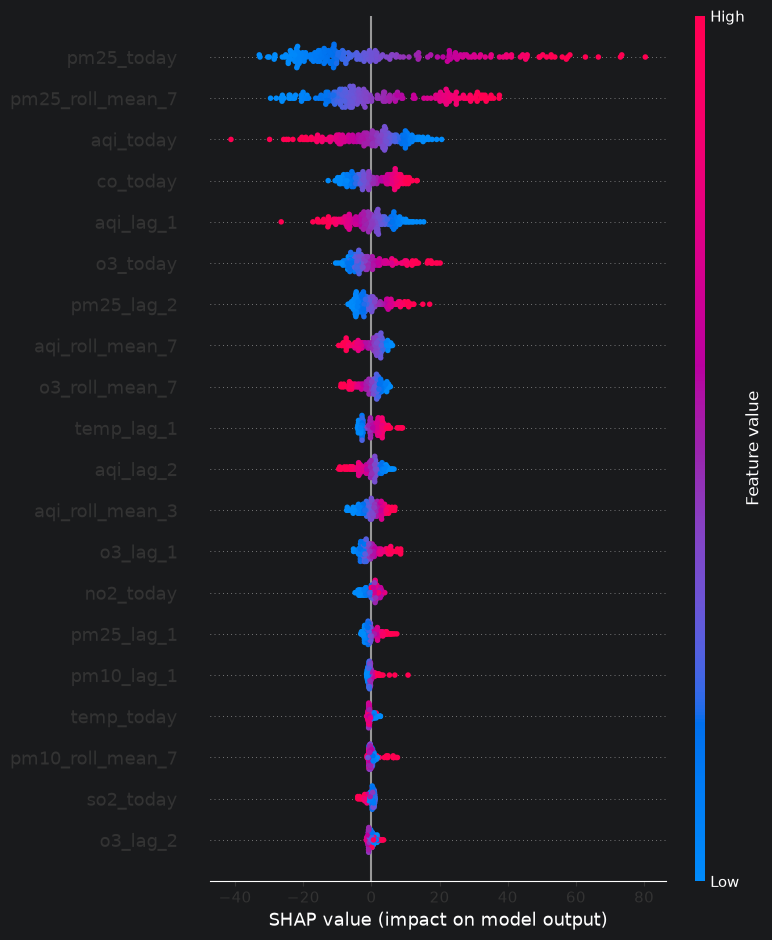

C:\Users\Lucky\AppData\Local\Temp\ipykernel_13304\24439805.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


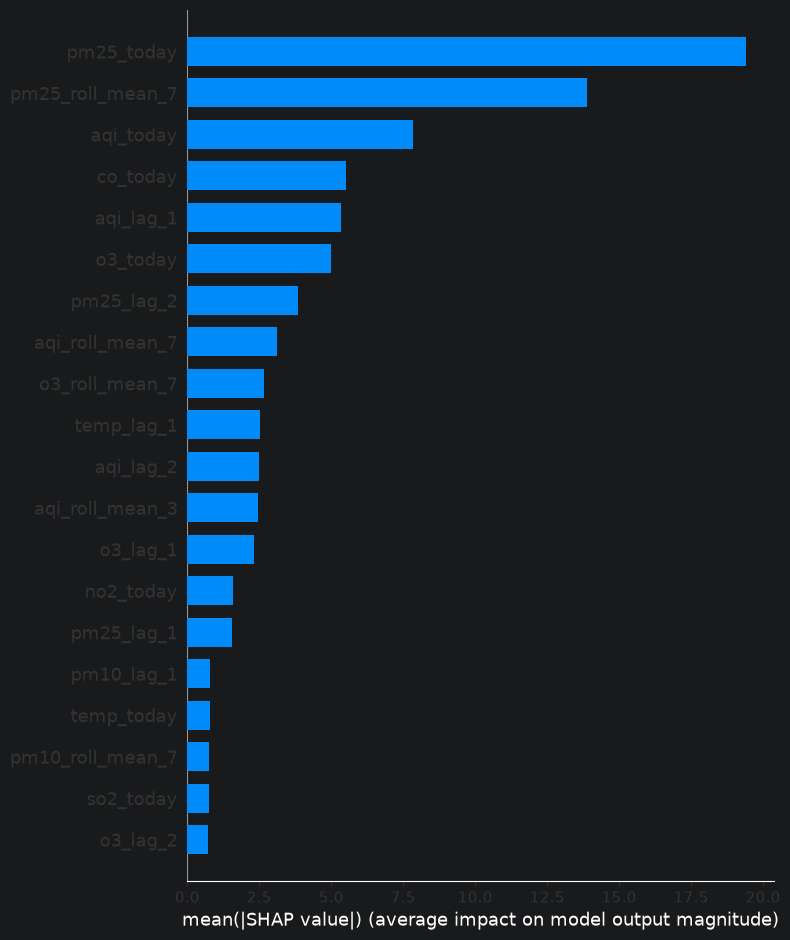

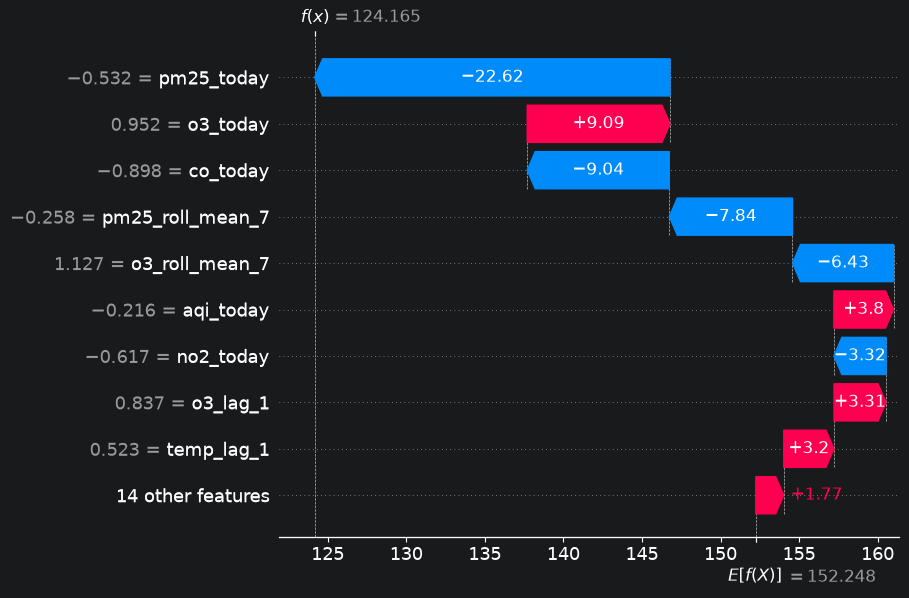

In [48]:
get_shap(MLP_DAY_2_RFECV_FEATURES, mlp_base_model_2_rfecv)

## SHAP Analysis — Day 2

### Beeswarm Plot
**Observation:** The beeswarm plot shows that `pm25_today` and `pm25_roll_mean_7` are the dominant drivers of the Day 2 MLP predictions, producing the widest SHAP dispersion. High values of these features, along with `co_today`, generally push predictions higher, while lower values pull them down. `aqi_today`, `aqi_lag_1`, and `aqi_lag_2` show an inverse relationship, while weather and minor gas features have comparatively little influence.

### Bar Plot
**Observation:** The mean absolute SHAP values confirm the dominance of `pm25_today` and `pm25_roll_mean_7`, with mean impacts of approximately **19.5** and **13.8**, respectively. `aqi_today`, `co_today`, `aqi_lag_1`, and `o3_today` form the secondary importance tier, while features such as `no2_today`, `temp_today`, and `so2_today` have minimal overall impact.

### Waterfall Plot
**Observation:** The waterfall plot provides a local explanation for a single Day 2 prediction, showing how feature contributions move the prediction from the expected model output of **152.248** to the final prediction of **124.165**. `pm25_today` produces the largest downward contribution (**-22.62**), followed by `co_today` (**-9.04**) and `pm25_roll_mean_7` (**-7.84**). `o3_today` provides the strongest upward contribution (**+9.09**), with additional positive effects from `aqi_today`, `o3_lag_1`, and `temp_lag_1`. Overall, the negative contributions outweigh the positive contributions, resulting in a prediction approximately **28 units below the expected output**.

E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_24
Received: inputs=['Tensor(shape=(100, 25))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_24
Received: inputs=['Tensor(shape=(200, 25))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_24
Re

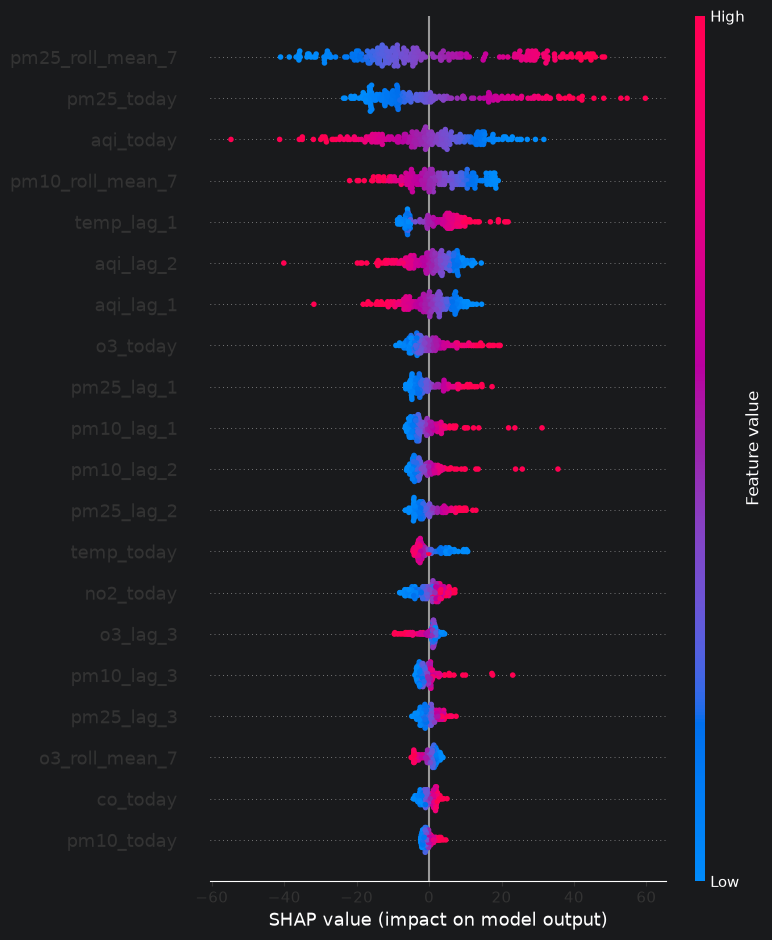

C:\Users\Lucky\AppData\Local\Temp\ipykernel_13304\24439805.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


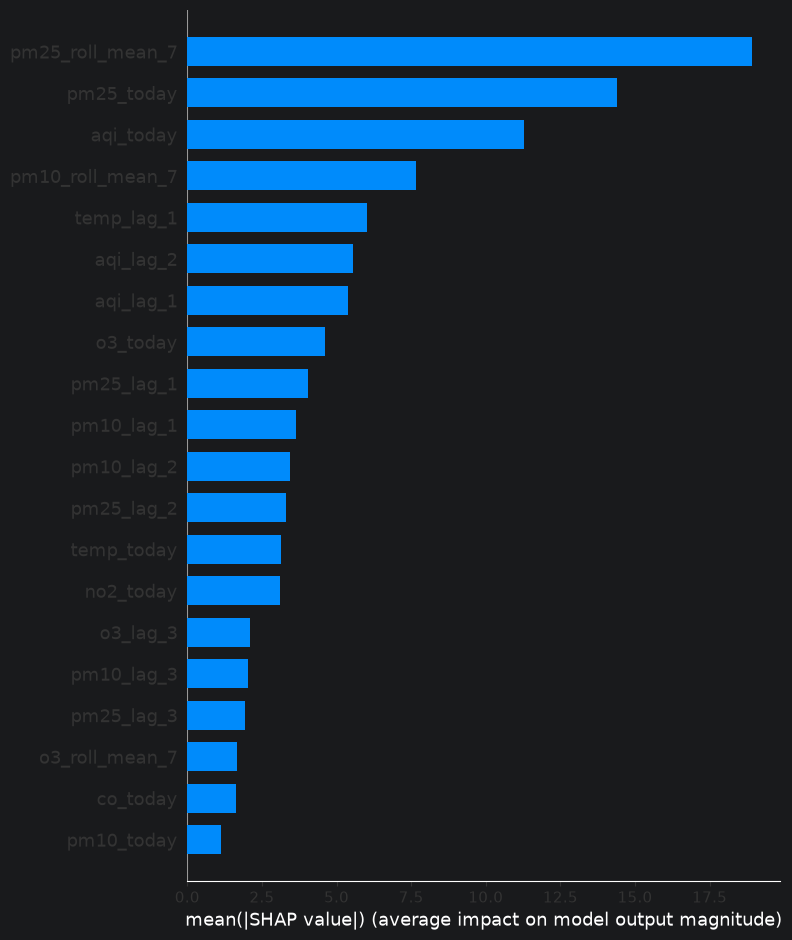

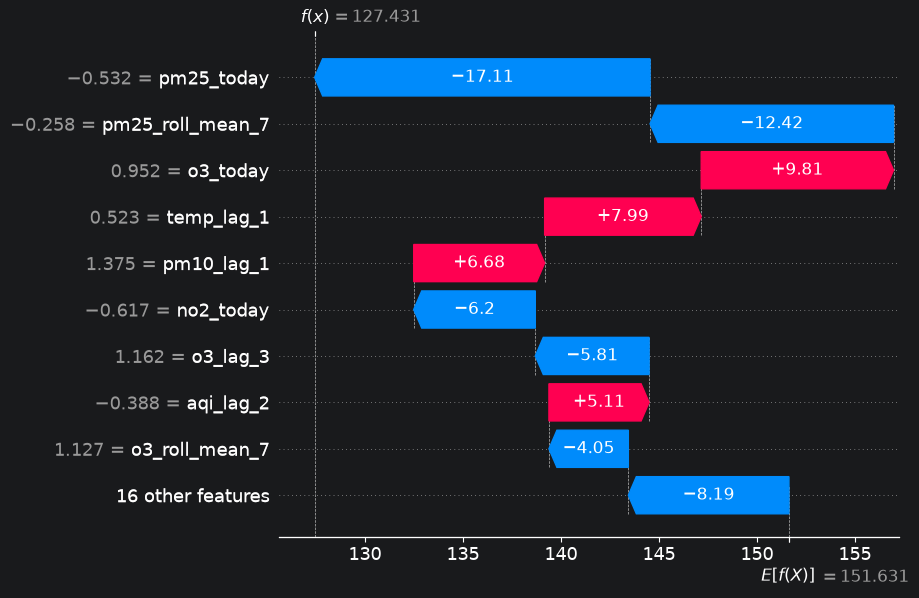

In [49]:
get_shap(MLP_DAY_3_RFECV_FEATURES, mlp_base_model_3_rfecv)

## SHAP Analysis — Day 3

### Beeswarm Plot
**Observation:** The beeswarm plot shows that `pm25_roll_mean_7` and `pm25_today` are the dominant drivers of the Day 3 MLP predictions, producing the widest SHAP dispersion. High values of these features and `temp_lag_1` generally push predictions higher, while `aqi_today`, `pm10_roll_mean_7`, `aqi_lag_2`, and `aqi_lag_1` show inverse effects. Particulate lag features provide additional positive signals, while features in the lower importance tail have minimal influence.

### Bar Plot
**Observation:** The mean absolute SHAP values confirm `pm25_roll_mean_7` as the most influential feature, with an average impact of approximately **18.8**, followed by `pm25_today` (**14.3**) and `aqi_today` (**11.2**). `pm10_roll_mean_7`, `temp_lag_1`, `aqi_lag_2`, and `aqi_lag_1` form the secondary importance tier, while features such as `o3_roll_mean_7`, `co_today`, and `pm10_today` contribute minimally.

### Waterfall Plot
**Observation:** The waterfall plot provides a local explanation for a single Day 3 prediction, showing how feature contributions move the prediction from the expected model output of **151.631** to the final prediction of **127.431**. `pm25_today` produces the largest downward contribution (**-17.11**), followed by `pm25_roll_mean_7` (**-12.42**). Positive contributions from `o3_today` (**+9.81**), `temp_lag_1` (**+7.99**), and `pm10_lag_1` (**+6.68**) partially offset these effects. Overall, the negative contributions outweigh the positive ones, resulting in a prediction approximately **24 units below the expected output**.

E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(100, 27))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Received: inputs=['Tensor(shape=(200, 27))']
  warnings.warn(msg)
E:\aura-pearls-aqi-predictor\.venv\Lib\site-packages\keras\src\models\functional.py:259: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_32
Re

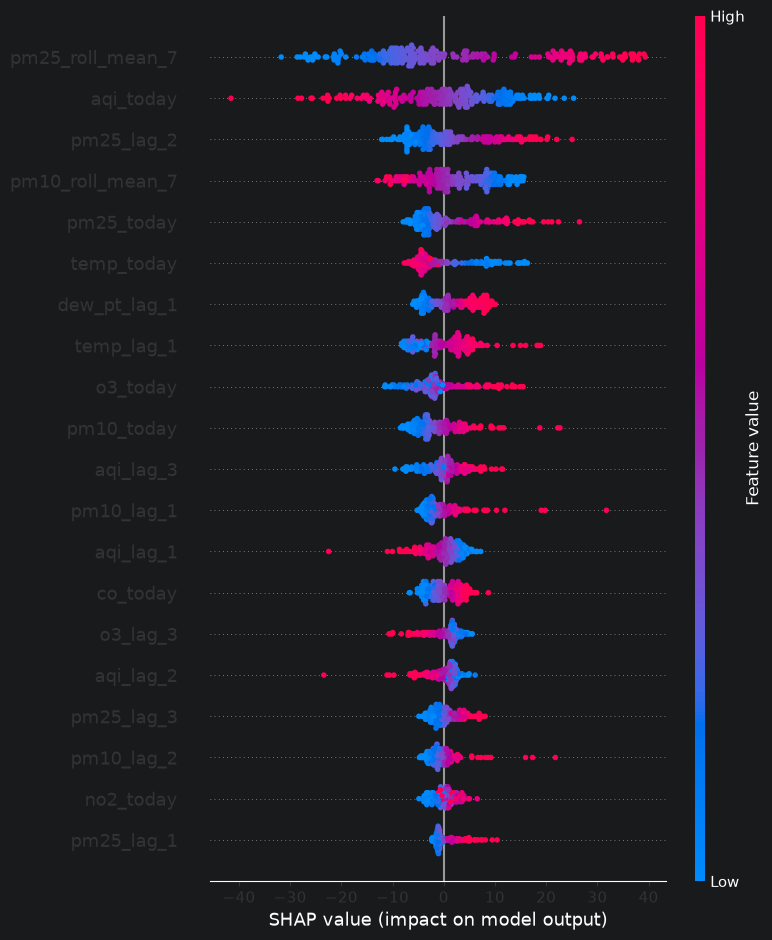

C:\Users\Lucky\AppData\Local\Temp\ipykernel_13304\24439805.py:38: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


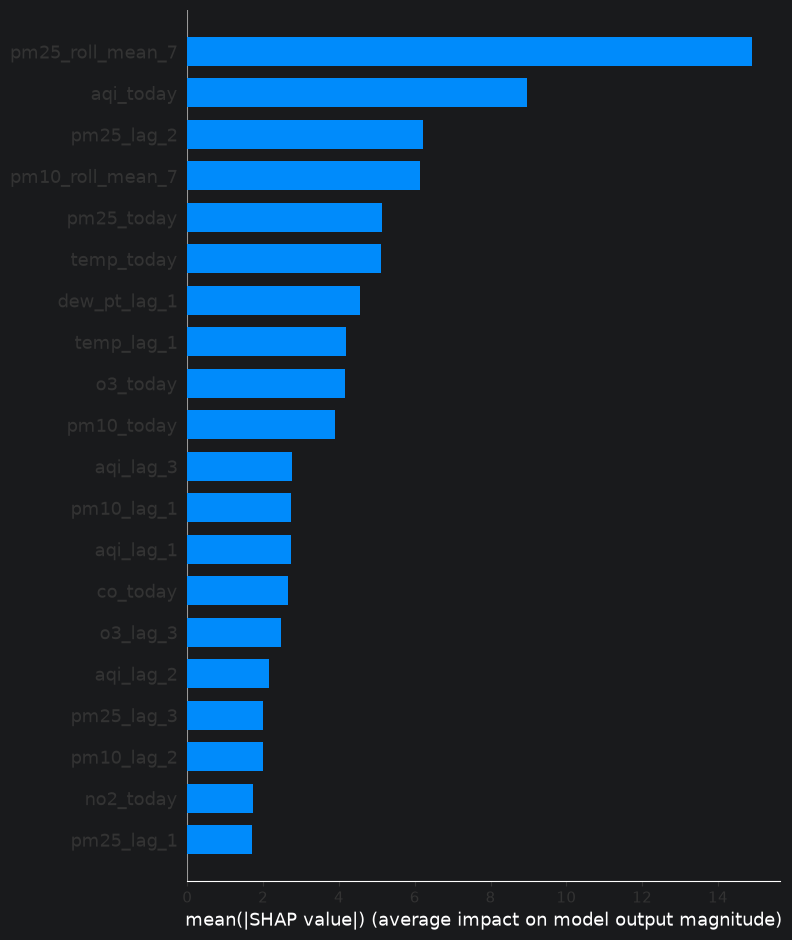

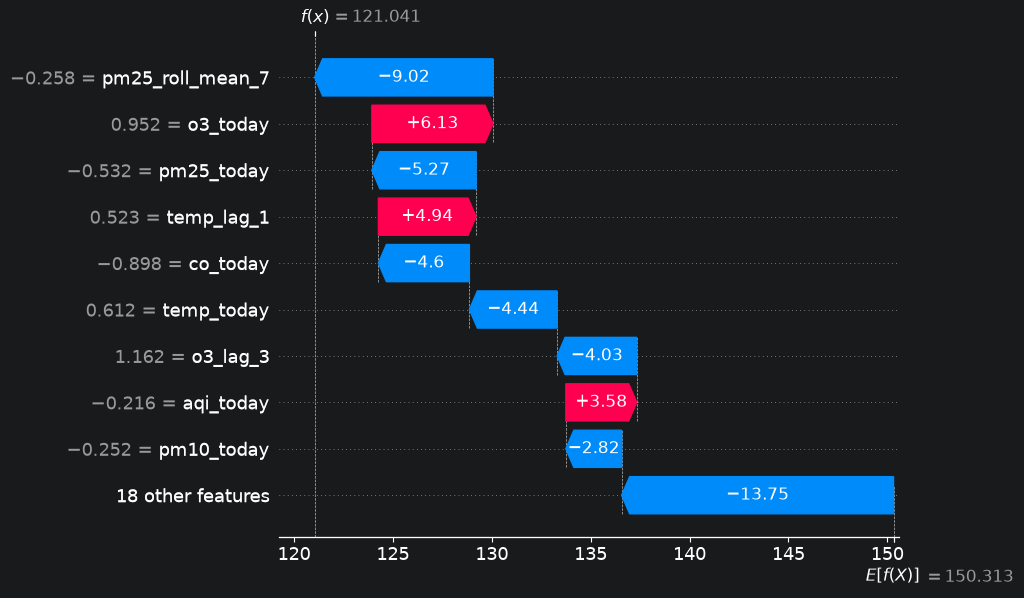

In [50]:
get_shap(MLP_DAY_4_RFECV_FEATURES, mlp_base_model_4_rfecv)

## SHAP Analysis — Day 4

### Beeswarm Plot
**Observation:** The beeswarm plot shows `pm25_roll_mean_7` as the dominant driver of the Day 4 MLP predictions, with high values generally pushing predictions higher and low values pulling them down. `aqi_today` and `temp_today` show inverse relationships, while lagged particulate and weather features provide additional positive signals. Features in the lower-ranked tail, including `no2_today` and `pm25_lag_1`, have minimal influence on model predictions.

### Bar Plot
**Observation:** The mean absolute SHAP values confirm `pm25_roll_mean_7` as the most influential feature, with an average impact of approximately **14.8**, followed by `aqi_today` (**9.0**). `pm25_lag_2` and `pm10_roll_mean_7` form the next importance tier at approximately **6.1**, followed by `pm25_today` and `temp_today`. Lower-ranked features such as `no2_today` and `pm25_lag_1` have comparatively minimal impact, remaining below **2.0** in mean SHAP magnitude.

### Waterfall Plot
**Observation:** The waterfall plot provides a local explanation for a single Day 4 prediction, showing how feature contributions move the prediction from the expected model output of **150.313** to the final prediction of **121.041**. `pm25_roll_mean_7` produces the largest named downward contribution (**-9.02**), followed by `pm25_today` (**-5.27**) and `co_today` (**-4.60**). The remaining features collectively contribute an additional **-13.75**, while positive contributions from `o3_today`, `temp_lag_1`, and `aqi_today` partially offset the downward forces. Overall, the negative contributions outweigh the positive ones, lowering the prediction by approximately **29 units below the expected output**.